In [30]:
!pip install labelme 

In [31]:
!pip install tensorflow

In [32]:
!pip install opencv-python matplotlib albumentations

## Colectarea imaginilor

In [7]:
import os
import time
import uuid
import cv2

In [25]:
labels = ['ILY']
number_imgs = 10
# 'thumbsup', 'thumbsdown','ok','victory','ILY'

In [26]:
IMAGES_PATH = os.path.join('Tensorflow', 'workspace', 'images', 'collectedimages')

In [8]:
if not os.path.exists(IMAGES_PATH):
    if os.name == 'posix':
        !mkdir -p {IMAGES_PATH}
    if os.name == 'nt':
         !mkdir {IMAGES_PATH}
for label in labels:
    path = os.path.join(IMAGES_PATH, label)
    if not os.path.exists(path):
        !mkdir {path}

# Capturarea imaginilor

In [28]:
for label in labels:
    cap = cv2.VideoCapture(0)
    print('Collecting images for {}'.format(label))
    time.sleep(5)
    for imgnum in range(number_imgs):
        print('Collecting image {}'.format(imgnum))
        ret, frame = cap.read()
        imgname = os.path.join(IMAGES_PATH,label,label+'.'+'{}.jpg'.format(str(uuid.uuid1())))
        cv2.imwrite(imgname, frame)
        cv2.imshow('frame', frame)
        time.sleep(2)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
cap.release()
cv2.destroyAllWindows()

# Lableimg

In [35]:
!pip install pyqt5

  Using cached PyQt5-5.15.10-cp37-abi3-win_amd64.whl.metadata (2.2 kB)
  Using cached PyQt5_sip-12.13.0-cp311-cp311-win_amd64.whl.metadata (524 bytes)
Using cached PyQt5-5.15.10-cp37-abi3-win_amd64.whl (6.8 MB)
Using cached PyQt5_Qt5-5.15.2-py3-none-win_amd64.whl (50.1 MB)
Using cached PyQt5_sip-12.13.0-cp311-cp311-win_amd64.whl (78 kB)


In [92]:
!labelme

C:\Users\popaz\anaconda3\Lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
C:\Users\popaz\anaconda3\Lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
C:\Users\popaz\anaconda3\Lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"
C:\Users\popaz\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,
2024-06-11 00:35:13,136 [INFO   ] __init__:get_config:67- Loading config file from: C:\Users\popaz\.labelmerc


In [6]:
import tensorflow as tf
import json
import numpy as np
from matplotlib import pyplot as plt

In [38]:
# Avoid OOM errors by setting GPU Memory Consumption Growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus: 
    tf.config.experimental.set_memory_growth(gpu, True)

In [40]:
tf.config.list_physical_devices('GPU')

[]

In [39]:
tf.test.is_gpu_available()

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


False

# 2. Examinarea setul de date

### 2.1 Import TF and Deps

In [5]:
import tensorflow as tf
import json
import numpy as np
from matplotlib import pyplot as plt

### 2.3 Load Image into TF Data Pipeline

In [44]:
images = tf.data.Dataset.list_files('data\\images\\*.jpg')

In [45]:
images.as_numpy_iterator().next()

b'data\\images\\thumbsdown.c413ae57-060a-11ef-9d40-a347a4ac4d1a.jpg'

In [9]:
def load_image(x): 
    byte_img = tf.io.read_file(x)
    img = tf.io.decode_jpeg(byte_img)
    return img

In [47]:
images = images.map(load_image)

In [48]:
images.as_numpy_iterator().next()

array([[[118, 121, 112],
        [118, 121, 112],
        [117, 123, 113],
        ...,
        [ 87,  87,  87],
        [ 87,  89,  88],
        [ 88,  90,  89]],

       [[114, 117, 108],
        [116, 122, 110],
        [117, 123, 113],
        ...,
        [ 88,  88,  88],
        [ 87,  89,  88],
        [ 87,  89,  88]],

       [[111, 117, 105],
        [117, 123, 109],
        [116, 124, 111],
        ...,
        [ 88,  90,  87],
        [ 87,  89,  86],
        [ 87,  89,  86]],

       ...,

       [[ 65,  54,  60],
        [ 72,  61,  69],
        [ 72,  62,  71],
        ...,
        [ 30,  29,  25],
        [ 28,  27,  23],
        [ 27,  26,  22]],

       [[ 63,  51,  61],
        [ 73,  61,  71],
        [ 71,  61,  70],
        ...,
        [ 29,  30,  24],
        [ 28,  27,  23],
        [ 27,  26,  22]],

       [[ 64,  52,  64],
        [ 72,  62,  73],
        [ 65,  55,  64],
        ...,
        [ 29,  30,  24],
        [ 27,  26,  22],
        [ 26,  25,  21]]

In [49]:
type(images)

tensorflow.python.data.ops.map_op._MapDataset

### 2.4 View Raw Images with Matplotlib

In [55]:
image_generator = images.batch(4).as_numpy_iterator()

In [56]:
plot_images = image_generator.next()

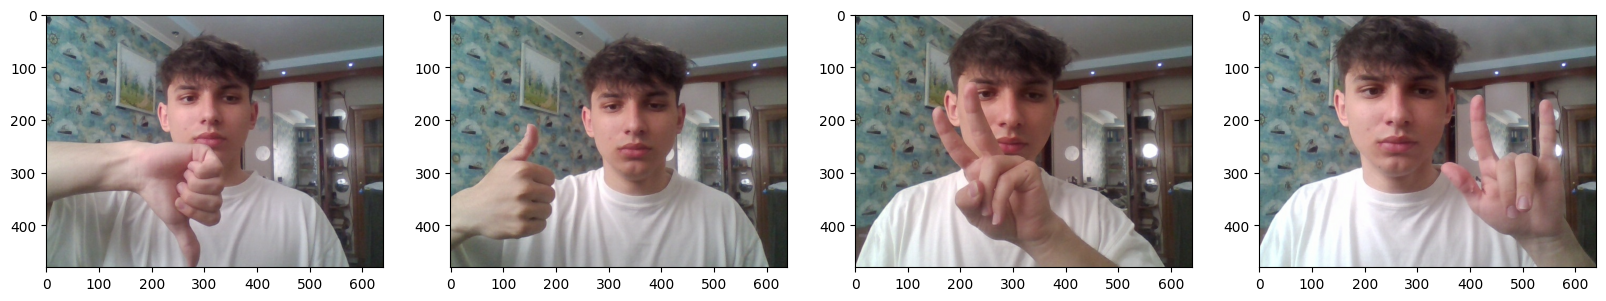

In [57]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, image in enumerate(plot_images):
    ax[idx].imshow(image) 
plt.show()

# 3. Partition Unaugmented Data

In [58]:
50*.7 # 35 to train

35.0

### 3.1 Move the Matching Labels

In [67]:
import os

# Parcurge folderele 'train', 'test' și 'val'
for folder in ['train', 'test', 'val']:
    # Obține lista de fișiere din directorul 'images' din folderul curent
    image_folder = os.path.join('C:/Users/popaz/Teza/TFODCourse/data', folder, 'images')
    for file in os.listdir(image_folder):
        # Extrage numele fișierului și construiește calea către fișierul .json corespunzător
        filename = file.rsplit('.', 1)[0] + '.json'
        existing_filepath = os.path.join('C:/Users/popaz/Teza/TFODCourse/data', 'labels', filename)
        
        # Verifică dacă fișierul .json există
        if os.path.exists(existing_filepath): 
            # Construiește noua cale de fișier pentru a-l muta în directorul corespunzător
            new_filepath = os.path.join('C:/Users/popaz/Teza/TFODCourse/data', folder, 'labels', filename)
            
            # Afișează căile de fișiere înainte și după operația de mutare
            print("Existing filepath:", existing_filepath)
            print("New filepath:", new_filepath)
            
            # Înlocuiește fișierul existent cu cel nou
            os.replace(existing_filepath, new_filepath)   
        else:
            # Afișează un mesaj de avertizare dacă fișierul .json nu există
            print(f"JSON file for {file} does not exist.")
     

Existing filepath: C:/Users/popaz/Teza/TFODCourse/data\labels\ILY.95d678e0-060b-11ef-9232-a347a4ac4d1a.json
New filepath: C:/Users/popaz/Teza/TFODCourse/data\train\labels\ILY.95d678e0-060b-11ef-9232-a347a4ac4d1a.json
Existing filepath: C:/Users/popaz/Teza/TFODCourse/data\labels\ILY.970ba522-060b-11ef-988d-a347a4ac4d1a.json
New filepath: C:/Users/popaz/Teza/TFODCourse/data\train\labels\ILY.970ba522-060b-11ef-988d-a347a4ac4d1a.json
Existing filepath: C:/Users/popaz/Teza/TFODCourse/data\labels\ILY.9d132828-060b-11ef-9c2c-a347a4ac4d1a.json
New filepath: C:/Users/popaz/Teza/TFODCourse/data\train\labels\ILY.9d132828-060b-11ef-9c2c-a347a4ac4d1a.json
Existing filepath: C:/Users/popaz/Teza/TFODCourse/data\labels\ILY.b86185ba-060b-11ef-bc9d-a347a4ac4d1a.json
New filepath: C:/Users/popaz/Teza/TFODCourse/data\train\labels\ILY.b86185ba-060b-11ef-bc9d-a347a4ac4d1a.json
Existing filepath: C:/Users/popaz/Teza/TFODCourse/data\labels\ILY.bacff02e-060b-11ef-a70a-a347a4ac4d1a.json
New filepath: C:/Users/p

# 4. Apply Image Augmentation on Images and Labels using Albumentations

### 4.1 Setup Albumentations Transform Pipeline

In [68]:
import albumentations as alb

In [69]:
augmentor = alb.Compose([alb.RandomCrop(width=450, height=450), 
                         alb.HorizontalFlip(p=0.5), 
                         alb.RandomBrightnessContrast(p=0.2),
                         alb.RandomGamma(p=0.2), 
                         alb.RGBShift(p=0.2), 
                         alb.VerticalFlip(p=0.5)], 
                       bbox_params=alb.BboxParams(format='albumentations', 
                                                  label_fields=['class_labels']))

### 4.2 Load a Test Image and Annotation with OpenCV and JSON

In [71]:
img = cv2.imread(os.path.join('data','train', 'images','ILY.9d132828-060b-11ef-9c2c-a347a4ac4d1a.jpg'))

In [72]:
img

array([[[125, 131, 114],
        [133, 139, 122],
        [137, 143, 124],
        ...,
        [109, 110, 101],
        [106, 109, 100],
        [107, 110, 101]],

       [[130, 136, 119],
        [133, 139, 120],
        [134, 140, 121],
        ...,
        [109, 110, 101],
        [107, 110, 101],
        [108, 111, 102]],

       [[133, 139, 120],
        [136, 143, 122],
        [137, 144, 123],
        ...,
        [107, 110, 101],
        [107, 110, 101],
        [107, 110, 101]],

       ...,

       [[ 70,  83,  91],
        [ 68,  81,  89],
        [ 65,  79,  85],
        ...,
        [ 32,  39,  32],
        [ 32,  39,  32],
        [ 32,  39,  32]],

       [[ 66,  82,  88],
        [ 64,  80,  86],
        [ 63,  79,  85],
        ...,
        [ 33,  40,  33],
        [ 32,  39,  32],
        [ 32,  39,  32]],

       [[ 63,  79,  85],
        [ 63,  79,  85],
        [ 62,  78,  84],
        ...,
        [ 34,  41,  34],
        [ 33,  40,  33],
        [ 32,  39,  32]]

In [73]:
with open(os.path.join('data', 'train', 'labels', 'ILY.9d132828-060b-11ef-9c2c-a347a4ac4d1a.json'), 'r') as f:
    label = json.load(f)

In [75]:
label['shapes'][0]['points']

[[58.372093023255786, 79.24418604651164], [320.0, 370.5232558139535]]

### 4.3 Extract Coordinates and Rescale to Match Image Resolution

In [76]:
coords = [0,0,0,0]
coords[0] = label['shapes'][0]['points'][0][0]
coords[1] = label['shapes'][0]['points'][0][1]
coords[2] = label['shapes'][0]['points'][1][0]
coords[3] = label['shapes'][0]['points'][1][1]

In [77]:
coords

[58.372093023255786, 79.24418604651164, 320.0, 370.5232558139535]

In [78]:
coords = list(np.divide(coords, [640,480,640,480]))

In [79]:
coords

[0.09120639534883716, 0.16509205426356593, 0.5, 0.7719234496124031]

### 4.4 Apply Augmentations and View Results

In [80]:
augmented = augmentor(image=img, bboxes=[coords], class_labels=['i love u'])

In [81]:
augmented['bboxes']

[(0.0, 0.21439276485788117, 0.5266666666666666, 0.8616795865633075)]

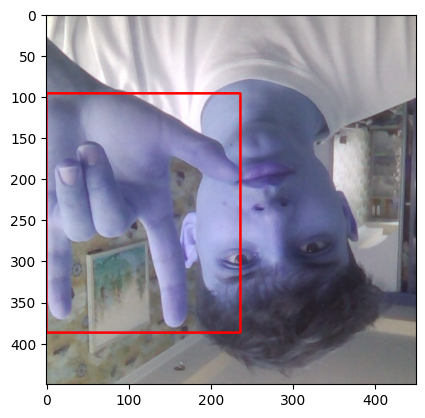

In [82]:
cv2.rectangle(augmented['image'], 
              tuple(np.multiply(augmented['bboxes'][0][:2], [450,450]).astype(int)),
              tuple(np.multiply(augmented['bboxes'][0][2:], [450,450]).astype(int)), 
                    (255,0,0), 2)

plt.imshow(augmented['image'])

# 5. Build and Run Augmentation Pipeline

### 5.1 Run Augmentation Pipeline

In [91]:
class_label = [ "i love u", "victory", "thumbsup", "thumbsown", "ok"]

class_mapping = {label: idx for idx, label in enumerate(class_labels)}

In [92]:
class_mapping

{'i love u': 0, 'victory': 1, 'thumbsup': 2, 'thumbsdown': 3, 'ok': 4}

In [93]:

for partition in ['train','test','val']: 
    for image in os.listdir(os.path.join('data', partition, 'images')):
        img = cv2.imread(os.path.join('data', partition, 'images', image))

        coords = [0,0,0.00001,0.00001]
        label_path = os.path.join('data', partition, 'labels', f'{image.rsplit(".", 1)[0]}.json')
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                label = json.load(f)

            coords[0] = label['shapes'][0]['points'][0][0]
            coords[1] = label['shapes'][0]['points'][0][1]
            coords[2] = label['shapes'][0]['points'][1][0]
            coords[3] = label['shapes'][0]['points'][1][1]
            coords = list(np.divide(coords, [640,480,640,480]))

        try: 
            for x in range(50):
                augmented = augmentor(image=img, bboxes=[coords], class_labels=[class_label])
                cv2.imwrite(os.path.join('aug_data', partition, 'images', f'{image.rsplit(".", 1)[0]}.{x}.jpg'), augmented['image'])

                annotation = {}
                annotation['image'] = image

                if os.path.exists(label_path):
                    if len(augmented['bboxes']) == 0: 
                        annotation['bbox'] = [0,0,0,0]
                        annotation['class'] = class_mapping[label['shapes'][0]['label']]
                    else: 
                        annotation['bbox'] = augmented['bboxes'][0]
                        annotation['class'] = class_mapping[label['shapes'][0]['label']]
                else: 
                    annotation['bbox'] = [0,0,0,0]
                    annotation['class'] = 0 


                with open(os.path.join('aug_data', partition, 'labels', f'{image.rsplit(".", 1)[0]}.{x}.json'), 'w') as f:
                    json.dump(annotation, f)

        except Exception as e:
            print(e)

In [99]:
img = cv2.imread(os.path.join('aug_data','test', 'images','ILY.983f7b54-060b-11ef-b6fc-a347a4ac4d1a.0.jpg'))

In [100]:
img

array([[[107, 116, 125],
        [102, 111, 120],
        [100, 109, 118],
        ...,
        [146, 146, 146],
        [153, 153, 153],
        [153, 155, 155]],

       [[109, 118, 127],
        [104, 113, 122],
        [102, 111, 120],
        ...,
        [150, 148, 148],
        [153, 153, 153],
        [151, 153, 153]],

       [[110, 119, 129],
        [107, 116, 126],
        [103, 112, 122],
        ...,
        [152, 150, 150],
        [154, 154, 154],
        [153, 153, 153]],

       ...,

       [[164, 161, 133],
        [156, 155, 127],
        [150, 149, 121],
        ...,
        [133, 129, 128],
        [133, 130, 126],
        [133, 130, 126]],

       [[158, 157, 131],
        [153, 155, 126],
        [149, 151, 122],
        ...,
        [133, 131, 130],
        [131, 130, 126],
        [132, 131, 127]],

       [[156, 157, 131],
        [153, 155, 126],
        [150, 152, 123],
        ...,
        [133, 131, 130],
        [132, 131, 127],
        [133, 132, 128]]

### 5.2 Load Augmented Images to Tensorflow Dataset

In [10]:
train_images = tf.data.Dataset.list_files('aug_data\\train\\images\\*.jpg', shuffle=False)
train_images = train_images.map(load_image)
train_images = train_images.map(lambda x: tf.image.resize(x, (120,120)))
train_images = train_images.map(lambda x: x/255)

In [11]:
test_images = tf.data.Dataset.list_files('aug_data\\test\\images\\*.jpg', shuffle=False)
test_images = test_images.map(load_image)
test_images = test_images.map(lambda x: tf.image.resize(x, (120,120)))
test_images = test_images.map(lambda x: x/255)

In [12]:
val_images = tf.data.Dataset.list_files('aug_data\\val\\images\\*.jpg', shuffle=False)
val_images = val_images.map(load_image)
val_images = val_images.map(lambda x: tf.image.resize(x, (120,120)))
val_images = val_images.map(lambda x: x/255)

In [13]:
train_images.as_numpy_iterator().next()

array([[[0.7567402 , 0.73615193, 0.73468137],
        [0.74129903, 0.740625  , 0.72408086],
        [0.7465686 , 0.7416667 , 0.7558824 ],
        ...,
        [0.59117645, 0.5833333 , 0.5872549 ],
        [0.5681372 , 0.5675245 , 0.57077205],
        [0.6023897 , 0.6145833 , 0.61905634]],

       [[0.38578433, 0.34558824, 0.37254903],
        [0.7547181 , 0.7581495 , 0.7400122 ],
        [0.7523897 , 0.76023287, 0.75533086],
        ...,
        [0.6014706 , 0.59362745, 0.60539216],
        [0.5745711 , 0.5706495 , 0.59068626],
        [0.6036152 , 0.611826  , 0.63143384]],

       [[0.36531863, 0.31041667, 0.30894607],
        [0.4004902 , 0.37849265, 0.3858456 ],
        [0.7810049 , 0.7762255 , 0.79969364],
        ...,
        [0.608701  , 0.60085785, 0.6047794 ],
        [0.5715686 , 0.56715685, 0.5857843 ],
        [0.6039216 , 0.60490197, 0.62469363]],

       ...,

       [[0.5205882 , 0.59546566, 0.5545956 ],
        [0.55202204, 0.60680145, 0.55716914],
        [0.559375  , 0

# 6. Prepare Labels

### 6.1 Build Label Loading Function

In [14]:
# def load_labels(label_path):
#     with open(label_path.numpy(), 'r', encoding = "utf-8") as f:
#         label = json.load(f)
        
#     return [label['class']], label['bbox']

def load_labels(label_path):
    with open(label_path.numpy(), 'r', encoding = "utf-8") as f:
        label = json.load(f)
    # Convert class label to one-hot encoding (assuming there are 5 classes)
    class_label = tf.one_hot(label['class'], depth=5)
    bbox = tf.convert_to_tensor(label['bbox'], dtype=tf.float32)
    return class_label, bbox

In [15]:
def load_labels_tf(x):
    class_label, bbox = tf.py_function(load_labels, [x], [tf.float32, tf.float32])
    class_label.set_shape([5])  # Set the shape for one-hot encoded labels
    bbox.set_shape([4])  # Set the shape for bounding boxes
    return class_label, bbox

### 6.2 Load Labels to Tensorflow Dataset

In [16]:
train_labels = tf.data.Dataset.list_files('aug_data\\train\\labels\\*.json', shuffle=False)
train_labels = train_labels.map(lambda x: load_labels_tf(x))

In [17]:
test_labels = tf.data.Dataset.list_files('aug_data\\test\\labels\\*.json', shuffle=False)
test_labels = test_labels.map(lambda x: load_labels_tf(x))

In [18]:
val_labels = tf.data.Dataset.list_files('aug_data\\val\\labels\\*.json', shuffle=False)
val_labels = val_labels.map(lambda x: load_labels_tf(x))

In [19]:
train_labels.as_numpy_iterator().next()

(array([1., 0., 0., 0., 0.], dtype=float32),
 array([0.07390181, 0.21620154, 0.66950905, 0.8609044 ], dtype=float32))

# 7. Combine Label and Image Samples

### 7.1 Check Partition Lengths

In [20]:
len(train_images), len(train_labels), len(test_images), len(test_labels), len(val_images), len(val_labels)

(1750, 1750, 500, 500, 250, 250)

### 7.2 Create Final Datasets (Images/Labels)

In [21]:
train = tf.data.Dataset.zip((train_images, train_labels))
train = train.shuffle(5000)
train = train.batch(4)
train = train.prefetch(4)

In [22]:
test = tf.data.Dataset.zip((test_images, test_labels))
test = test.shuffle(1300)
test = test.batch(4)
test = test.prefetch(4)

In [23]:
val = tf.data.Dataset.zip((val_images, val_labels))
val = val.shuffle(1000)
val = val.batch(4)
val = val.prefetch(4)

In [24]:
train.as_numpy_iterator().next()[1]

(array([[0., 1., 0., 0., 0.],
        [1., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0.],
        [0., 1., 0., 0., 0.]], dtype=float32),
 array([[0.25860465, 0.        , 0.7676486 , 0.77413434],
        [0.36      , 0.15387596, 0.94139534, 0.8011628 ],
        [0.5635659 , 0.16462532, 0.9847545 , 0.8506718 ],
        [0.24062015, 0.18731266, 0.7302842 , 0.8798191 ]], dtype=float32))

### 7.3 View Images and Annotations

In [93]:
data_samples = train.as_numpy_iterator()

In [94]:
res = data_samples.next()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


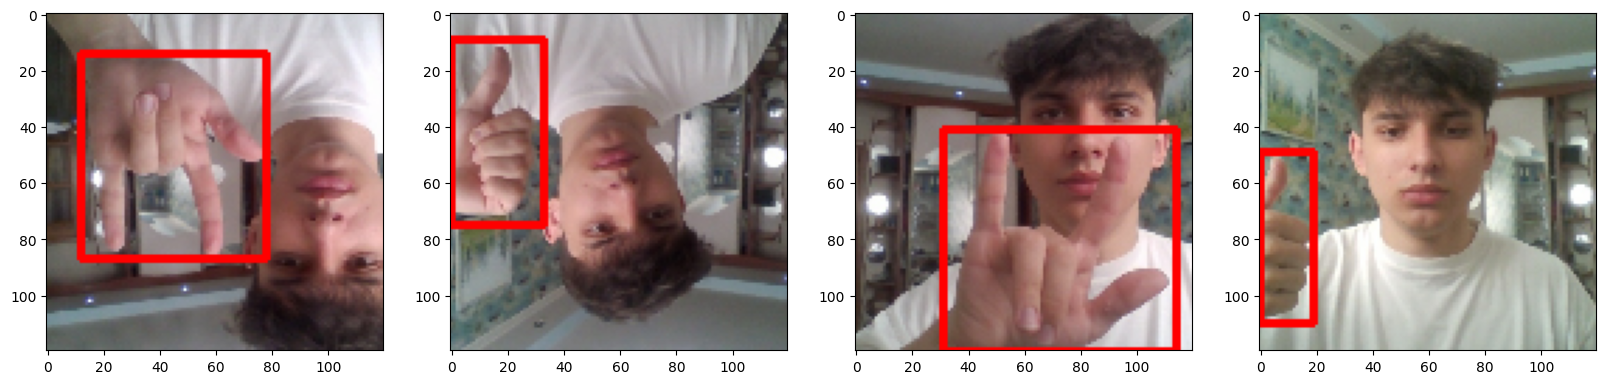

In [95]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx in range(4): 
    sample_image = res[0][idx]
    sample_coords = res[1][1][idx]
    
    # Convertiți imaginea NumPy într-un obiect cv::UMat
    sample_image_umat = cv2.UMat(sample_image)

    # Desenați caseta delimitatoare folosind obiectul cv::UMat
    cv2.rectangle(sample_image_umat, 
                  tuple(np.multiply(sample_coords[:2], [120,120]).astype(int)),
                  tuple(np.multiply(sample_coords[2:], [120,120]).astype(int)), 
                  (255,0,0), 2)

    ax[idx].imshow(cv2.UMat.get(sample_image_umat))  # Conversia înapoi la NumPy array pentru afișare

plt.show()

# 8. Build Deep Learning using the Functional API

### 8.1 Import Layers and Base Network

In [28]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Dense, GlobalMaxPooling2D,Flatten
from tensorflow.keras.applications import VGG16
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D
from tensorflow.keras.optimizers import Adam

### 8.2 Download VGG16

In [29]:
vgg = VGG16(include_top=False)

In [30]:
vgg.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, None, None, 3)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, None, None, 64)      │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, None, None, 64)      │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, None, None, 64)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, None, None, 128)     │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, None, None, 128)     │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, None, None, 128)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, None, None, 256)     │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, None, None, 256)     │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, None, None, 256)     │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, None, None, 256)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, None, None, 512)     │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, None, None, 512)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, None, None, 512)     │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

### 8.3 Build instance of Network

In [31]:

def build_model(input_shape=(120,120,3), num_classes=5):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False

    x = y = Flatten()(base_model.output)
    x = Dense(512, activation = 'relu')(x)
    x = Dropout(0.25)(x)
    x = Dense(512, activation = 'relu')(x)
    x = Dropout(0.25)(x)
    classification_preds = Dense(num_classes,name = 'class_label', activation = 'softmax')(x)

    y = Dense(256, activation = 'relu')(y)
    y = Dense(128, activation = 'relu')(y)
    y = Dense(64, activation = 'relu')(y)
    y = Dense(32, activation = 'relu')(y)
    bbox_preds = Dense(4, name = 'bounding_box', activation = 'sigmoid')(y)

    # Crearea modelului final
    model = Model(inputs=base_model.input, outputs = (classification_preds,bbox_preds))


    return model

### 8.4 Test out Neural Network

In [32]:
facetracker = build_model()

In [33]:
facetracker.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 120, 120, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv1 (Conv2D)         │ (None, 120, 120, 64)      │           1,792 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv2 (Conv2D)         │ (None, 120, 120, 64)      │          36,928 │ block1_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_pool (MaxPooling2D)    │ (None, 60, 60, 64)        │               0 │ block1_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_conv1 (Conv2D)         │ (None, 60, 60, 128)       │          73,856 │ block1_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_conv2 (Conv2D)         │ (None, 60, 60, 128)       │         147,584 │ block2_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_pool (MaxPooling2D)    │ (None, 30, 30, 128)       │               0 │ block2_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_conv1 (Conv2D)         │ (None, 30, 30, 256)       │         295,168 │ block2_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_conv2 (Conv2D)         │ (None, 30, 30, 256)       │         590,080 │ block3_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_conv3 (Conv2D)         │ (None, 30, 30, 256)       │         590,080 │ block3_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_pool (MaxPooling2D)    │ (None, 15, 15, 256)       │               0 │ block3_conv3[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_conv1 (Conv2D)         │ (None, 15, 15, 512)       │       1,180,160 │ block3_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_conv2 (Conv2D)         │ (None, 15, 15, 512)       │       2,359,808 │ block4_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_conv3 (Conv2D)         │ (None, 15, 15, 512)       │       2,359,808 │ block4_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_pool (MaxPooling2D)    │ (None, 7, 7, 512)         │               0 │ block4_conv3[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block5_conv1 (Conv2D)         │ (None, 7, 7, 512)         │       2,359,808 │ block4_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block5_conv2 (Conv2D)         │ (None, 7, 7, 512)         │       2,359,808 │ block5_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 18,562,985 (70.81 MB)

 Trainable params: 3,848,297 (14.68 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [34]:
X, y = train.as_numpy_iterator().next()

In [35]:
X.shape

(4, 120, 120, 3)

In [36]:
classes, coords = facetracker.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 834ms/step


In [37]:
classes, coords

(array([[0.13897762, 0.13150233, 0.23637341, 0.39477935, 0.09836723],
        [0.10205688, 0.09203657, 0.37035778, 0.32623446, 0.10931436],
        [0.14326054, 0.1332433 , 0.19302645, 0.39291406, 0.13755569],
        [0.16636012, 0.12677592, 0.25051242, 0.29804164, 0.1583099 ]],
       dtype=float32),
 array([[0.528455  , 0.46608877, 0.480807  , 0.5588791 ],
        [0.5488132 , 0.40497705, 0.56050813, 0.524424  ],
        [0.45861343, 0.4095271 , 0.52181834, 0.54061586],
        [0.5049786 , 0.4145491 , 0.53985226, 0.5377915 ]], dtype=float32))

# 9. Define Losses and Optimizers

### 9.1 Define Optimizer and LR

In [38]:
len(train)

438

In [39]:
batches_per_epoch = len(train)
lr_decay = (1./0.75 -1)/batches_per_epoch

In [40]:
lr_decay

0.0007610350076103499

In [41]:
opt = tf.keras.optimizers.Adam(learning_rate=0.0001, decay=lr_decay)

C:\Users\popaz\Teza\TFODCourse\tfod1\Lib\site-packages\keras\src\optimizers\base_optimizer.py:33: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


### 9.2 Create Localization Loss and Classification Loss

In [42]:
def localization_loss(y_true, yhat):            
    delta_coord = tf.reduce_sum(tf.square(y_true[:,:2] - yhat[:,:2]))
                  
    h_true = y_true[:,3] - y_true[:,1] 
    w_true = y_true[:,2] - y_true[:,0] 

    h_pred = yhat[:,3] - yhat[:,1] 
    w_pred = yhat[:,2] - yhat[:,0] 
    
    delta_size = tf.reduce_sum(tf.square(w_true - w_pred) + tf.square(h_true-h_pred))
    
    return delta_coord + delta_size

In [43]:
classloss = tf.keras.losses.CategoricalCrossentropy()
regressloss = localization_loss

### 9.3 Test out Loss Metrics

In [44]:
localization_loss(y[1], coords)

<tf.Tensor: shape=(), dtype=float32, numpy=1.8172845>

In [45]:
classloss(y[0], classes)

<tf.Tensor: shape=(), dtype=float32, numpy=1.0168501>

In [46]:
regressloss(y[1], coords)

<tf.Tensor: shape=(), dtype=float32, numpy=1.8172845>

In [47]:
output = facetracker.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step


In [48]:
class FaceTracker(Model): 
    def __init__(self, eyetracker,  **kwargs): 
        super().__init__(**kwargs)
        self.model = eyetracker

    def compile(self, opt, classloss, localizationloss, **kwargs):
        super().compile(**kwargs)
        self.closs = classloss
        self.lloss = localizationloss
        self.opt = opt
    
    def train_step(self, batch, **kwargs): 
        
        X, y = batch
        
        with tf.GradientTape() as tape: 
            classes, coords = self.model(X, training=True)
            
            batch_classloss = self.closs(y[0], classes)
            batch_localizationloss = self.lloss(tf.cast(y[1], tf.float32), coords)
            
            total_loss = batch_localizationloss+0.5*batch_classloss
            
            grad = tape.gradient(total_loss, self.model.trainable_variables)
        
        opt.apply_gradients(zip(grad, self.model.trainable_variables))
        
        return {"total_loss":total_loss, "class_loss":batch_classloss, "regress_loss":batch_localizationloss}
    
    def test_step(self, batch, **kwargs): 
        X, y = batch
        
        classes, coords = self.model(X, training=False)
        
        batch_classloss = self.closs(y[0], classes)
        batch_localizationloss = self.lloss(tf.cast(y[1], tf.float32), coords)
        total_loss = batch_localizationloss+0.5*batch_classloss
        
        return {"total_loss":total_loss, "class_loss":batch_classloss, "regress_loss":batch_localizationloss}
        
    def call(self, X, **kwargs): 
        return self.model(X, **kwargs)

In [49]:
model = FaceTracker(facetracker)

In [50]:
model.compile(opt, classloss, regressloss)

In [51]:
logdir='logs'

In [52]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [68]:
hist = model.fit(train, epochs=20, validation_data=val, callbacks=[tensorboard_callback])

Epoch 1/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 184s 414ms/step - class_loss: 2.5514e-04 - regress_loss: 0.0029 - total_loss: 0.0030 - val_class_loss: 0.0044 - val_regress_loss: 0.0281 - val_total_loss: 0.0303
Epoch 2/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 180s 405ms/step - class_loss: 5.6934e-04 - regress_loss: 0.0021 - total_loss: 0.0024 - val_class_loss: 2.6768 - val_regress_loss: 0.0683 - val_total_loss: 1.4067
Epoch 3/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 180s 406ms/step - class_loss: 0.0161 - regress_loss: 0.0023 - total_loss: 0.0103 - val_class_loss: 3.1391 - val_regress_loss: 0.0651 - val_total_loss: 1.6347
Epoch 4/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 178s 402ms/step - class_loss: 7.4258e-04 - regress_loss: 0.0027 - total_loss: 0.0031 - val_class_loss: 2.6264e-04 - val_regress_loss: 0.0073 - val_total_loss: 0.0074
Epoch 5/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 181s 408ms/step - class_loss: 0.0149 - regress_loss: 0.0027 - total_loss: 0.0102 - val_class_loss: 0.0347 - val_regress_loss: 0.0670 - val_total_loss: 0

In [69]:
hist.history

{'class_loss': [7.748598704893084e-07,
  8.939897088566795e-05,
  5.9604641222676946e-08,
  2.5867746444419026e-05,
  3.5762775496550603e-07,
  6.55650637781946e-07,
  0.0,
  4.7683693082944956e-07,
  5.9604641222676946e-08,
  0.0,
  1.1920927533992653e-07,
  0.0,
  3.397453156139818e-06,
  0.0,
  0.0,
  0.0,
  0.0,
  8.642607099318411e-06,
  0.0,
  0.0],
 'regress_loss': [0.001431171433068812,
  0.0023173699155449867,
  0.0015140925534069538,
  0.0011045539285987616,
  0.0016022430500015616,
  0.0010526550468057394,
  0.0003366338787600398,
  0.0006293332553468645,
  0.0007100452203303576,
  0.0015006777830421925,
  0.00034849761868827045,
  0.0015525517519563437,
  0.0019316553371027112,
  0.0006821676506660879,
  0.0008300918852910399,
  0.0006009379867464304,
  0.0008775169844739139,
  0.00044525775592774153,
  0.00037337496178224683,
  0.0007963465177454054],
 'total_loss': [0.001431558863259852,
  0.0023620694410055876,
  0.0015141223557293415,
  0.0011174877872690558,
  0.001602

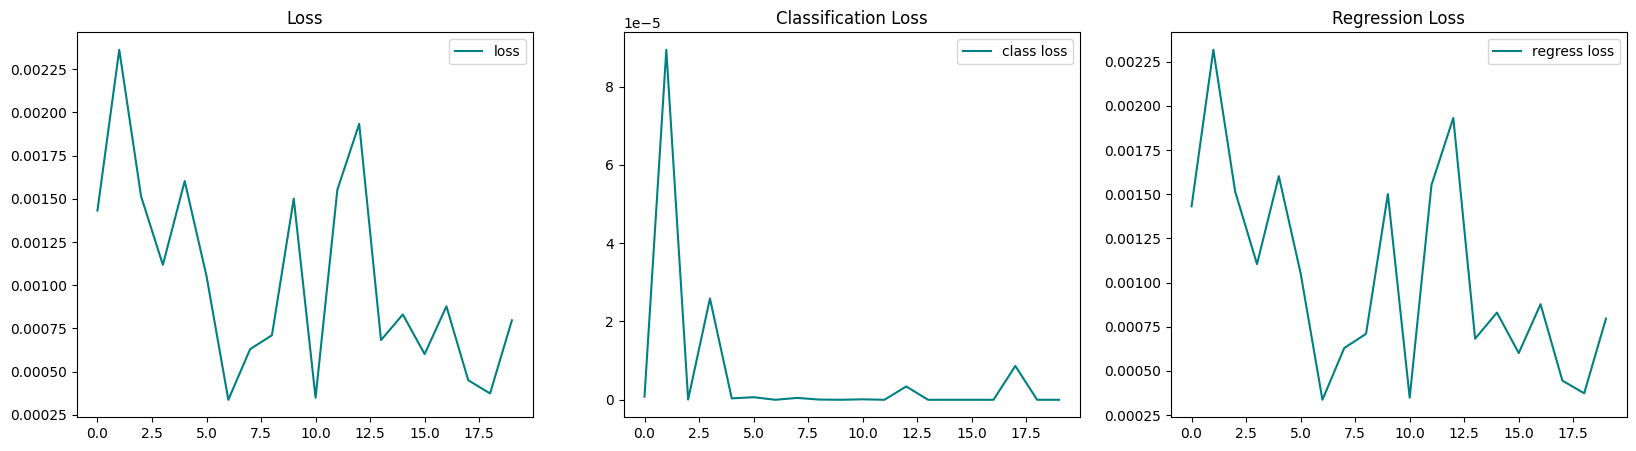

In [87]:
fig, ax = plt.subplots(ncols=3, figsize=(20,5))

ax[0].plot(hist.history['total_loss'], color='teal', label='loss')
# ax[0].plot(hist.history['val_total_loss'], color='orange', label='val loss')
ax[0].title.set_text('Loss')
ax[0].legend()

ax[1].plot(hist.history['class_loss'], color='teal', label='class loss')
# ax[1].plot(hist.history['val_class_loss'], color='orange', label='val class loss')
ax[1].title.set_text('Classification Loss')
ax[1].legend()

ax[2].plot(hist.history['regress_loss'], color='teal', label='regress loss')
# ax[2].plot(hist.history['val_regress_loss'], color='orange', label='val regress loss')
ax[2].title.set_text('Regression Loss')
ax[2].legend()

plt.show()

In [88]:
test_data = test.as_numpy_iterator()


In [89]:
test_sample = test_data.next()

In [90]:
yhat = facetracker.predict(test_sample[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 717ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Image 0
Coordinates: [0.0043205  0.4101444  0.3134818  0.97487676]
Confidence: 1.0
Image 1
Coordinates: [0.00167177 0.03594555 0.2492344  0.7825083 ]
Confidence: 1.0
Image 2
Coordinates: [0.55574    0.02661266 0.9709858  0.63124037]
Confidence: 1.0
Image 3
Coordinates: [0.00193171 0.00932489 0.17279574 0.6829062 ]
Confidence: 1.0


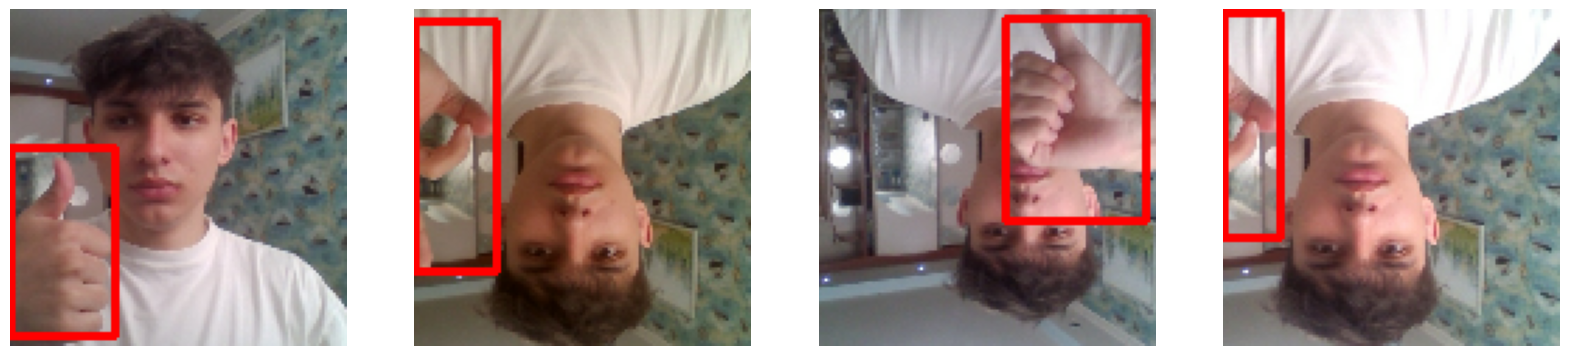

In [91]:
fig, ax = plt.subplots(ncols=4, figsize=(20, 20))

# Adjusting confidence threshold for debugging
confidence_threshold = 0.5

for idx in range(4):
    sample_image = test_sample[0][idx].copy()  # Make a writable copy of the image
    sample_coords = yhat[1][idx]
    confidence = np.max(yhat[0][idx])
    
    # Debug print statements
    print(f"Image {idx}")
    print(f"Coordinates: {sample_coords}")
    print(f"Confidence: {confidence}")

    # Check if the maximum probability in the class prediction is greater than the threshold
    if confidence > confidence_threshold:
        start_point = tuple(np.multiply(sample_coords[:2], [120, 120]).astype(int))
        end_point = tuple(np.multiply(sample_coords[2:], [120, 120]).astype(int))
        
        # Ensure coordinates are within bounds
        start_point = (max(0, start_point[0]), max(0, start_point[1]))
        end_point = (min(120, end_point[0]), min(120, end_point[1]))
        
        cv2.rectangle(sample_image, start_point, end_point, (255, 0, 0), 2)
    
    ax[idx].imshow(sample_image)
    ax[idx].axis('off')

plt.show()